In [1]:
# ============================================================
# CAPSTONE PROJECT - VERSION 3
# PART 1 : DATA ACQUISITION & INITIAL EXPLORATION
# ============================================================

import os
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ============================================================
# Create Required Folders
# ============================================================

OUTPUT_DIR = "output"
IMAGE_DIR = "images"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

# ============================================================
# Load Dataset
# ============================================================

DATASET_PATH = "Data Warehouse Multiclass.csv"

df = pd.read_csv(DATASET_PATH)

print("="*90)
print("CAPSTONE PROJECT - VERSION 3")
print("PART 1 : DATA ACQUISITION & INITIAL EXPLORATION")
print("="*90)

print("\nDataset Loaded Successfully.")

# ============================================================
# Dataset Shape
# ============================================================

print("\nDataset Shape")
print("-"*90)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

# ============================================================
# First Five Rows
# ============================================================

print("\nFirst Five Rows")
print("-"*90)

display(df.head())

# ============================================================
# Column Names
# ============================================================

print("\nColumn Names")
print("-"*90)

for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

# ============================================================
# Data Types
# ============================================================

print("\nColumn Data Types")
print("-"*90)

dtype_df = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.values
})

display(dtype_df)

dtype_df.to_csv(
    os.path.join(OUTPUT_DIR, "column_dtypes.csv"),
    index=False
)

# ============================================================
# Dataset Information
# ============================================================

print("\nDataset Information")
print("-"*90)

df.info()

# ============================================================
# Numeric & Categorical Columns
# ============================================================

numeric_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("\nNumeric Columns :", len(numeric_columns))
print(numeric_columns)

print("\nCategorical Columns :", len(categorical_columns))
print(categorical_columns)

CAPSTONE PROJECT - VERSION 3
PART 1 : DATA ACQUISITION & INITIAL EXPLORATION

Dataset Loaded Successfully.

Dataset Shape
------------------------------------------------------------------------------------------
Rows    : 280,985
Columns : 39

First Five Rows
------------------------------------------------------------------------------------------


,composite_key,age_level,gender,bmi_level,smoking,diabetes,age,age_normalized,bmi,hypertension,...,salt_intake,heart_rate,hdl,ldl,education_level,employment_status,source_dataset,disease_flags,sublabel,label
0,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,9,0.080460,19.20,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
1,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.55,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
2,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,22.89,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
3,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,3,0.011494,23.12,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal
4,Young_Female_Normal_Never_No,Young,Female,Normal,Never,No,4,0.022989,19.61,0.0,...,8.685304,74.329073,65.651757,129.220447,Primary,Retired,diabetes,"0,0,0",N,Normal



Column Names
------------------------------------------------------------------------------------------
01. composite_key
02. age_level
03. gender
04. bmi_level
05. smoking
06. diabetes
07. age
08. age_normalized
09. bmi
10. hypertension
11. heart_disease
12. HbA1c_level
13. glucose
14. cholesterol
15. sleep_hours
16. triglycerides
17. physical_activity
18. family_history
19. stress_level
20. low_hdl_cholesterol
21. high_ldl_cholesterol
22. blood_pressure
23. high_blood_pressure
24. sugar_consumption
25. crp_level
26. homocysteine_level
27. systolic_bp
28. diastolic_bp
29. alcohol_intake
30. salt_intake
31. heart_rate
32. hdl
33. ldl
34. education_level
35. employment_status
36. source_dataset
37. disease_flags
38. sublabel
39. label

Column Data Types
------------------------------------------------------------------------------------------


,Column,Data Type
0,composite_key,str
1,age_level,str
2,gender,str
3,bmi_level,str
4,smoking,str
5,diabetes,str
6,age,int64
7,age_normalized,float64
8,bmi,float64
9,hypertension,float64



Dataset Information
------------------------------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 280985 entries, 0 to 280984
Data columns (total 39 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   composite_key         280985 non-null  str    
 1   age_level             280985 non-null  str    
 2   gender                280985 non-null  str    
 3   bmi_level             280985 non-null  str    
 4   smoking               280985 non-null  str    
 5   diabetes              280985 non-null  str    
 6   age                   280985 non-null  int64  
 7   age_normalized        280985 non-null  float64
 8   bmi                   280985 non-null  float64
 9   hypertension          280985 non-null  float64
 10  heart_disease         280985 non-null  float64
 11  HbA1c_level           280985 non-null  float64
 12  glucose               280985 non-null  float64
 13  cho

In [2]:
# ============================================================
# MISSING VALUE ANALYSIS
# ============================================================

print("\n" + "="*90)
print("MISSING VALUE ANALYSIS")
print("="*90)

missing_count = df.isnull().sum()

missing_percentage = (
    missing_count / len(df)
) * 100

missing_df = pd.DataFrame({

    "Column": df.columns,

    "Missing Count": missing_count.values,

    "Missing Percentage": missing_percentage.round(2)

})

missing_df = missing_df.sort_values(
    by="Missing Percentage",
    ascending=False
)

display(missing_df)

missing_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "missing_value_report.csv"
    ),
    index=False
)

# ============================================================
# Columns Greater Than 20% Missing
# ============================================================

print("\nColumns Having More Than 20% Missing Values")
print("-"*90)

high_null = missing_df[
    missing_df["Missing Percentage"] > 20
]

if len(high_null)==0:

    print("No columns exceed 20% missing values.")

else:

    display(high_null)

# ============================================================
# Median Imputation (<20%)
# ============================================================

print("\nApplying Median Imputation")

imputed_columns=[]

for col in numeric_columns:

    percent = (
        df[col].isnull().sum()/len(df)
    )*100

    if 0 < percent < 20:

        median = df[col].median()

        df[col].fillna(
            median,
            inplace=True
        )

        imputed_columns.append(col)

if len(imputed_columns)==0:

    print("No numeric columns required imputation.")

else:

    print("Median Imputation Completed")

    for col in imputed_columns:

        print("✔",col)

print("\nRemaining Missing Values")

display(df.isnull().sum())


MISSING VALUE ANALYSIS


,Column,Missing Count,Missing Percentage
composite_key,composite_key,0,0.0
age_level,age_level,0,0.0
gender,gender,0,0.0
bmi_level,bmi_level,0,0.0
smoking,smoking,0,0.0
diabetes,diabetes,0,0.0
age,age,0,0.0
age_normalized,age_normalized,0,0.0
bmi,bmi,0,0.0
hypertension,hypertension,0,0.0



Columns Having More Than 20% Missing Values
------------------------------------------------------------------------------------------
No columns exceed 20% missing values.

Applying Median Imputation
No numeric columns required imputation.

Remaining Missing Values


composite_key           0
age_level               0
gender                  0
bmi_level               0
smoking                 0
diabetes                0
age                     0
age_normalized          0
bmi                     0
hypertension            0
heart_disease           0
HbA1c_level             0
glucose                 0
cholesterol             0
sleep_hours             0
triglycerides           0
physical_activity       0
family_history          0
stress_level            0
low_hdl_cholesterol     0
high_ldl_cholesterol    0
blood_pressure          0
high_blood_pressure     0
sugar_consumption       0
crp_level               0
homocysteine_level      0
systolic_bp             0
diastolic_bp            0
alcohol_intake          0
salt_intake             0
heart_rate              0
hdl                     0
ldl                     0
education_level         0
employment_status       0
source_dataset          0
disease_flags           0
sublabel                0
label       

In [3]:
# ============================================================
# DUPLICATE ANALYSIS
# ============================================================

print("\n" + "="*90)
print("DUPLICATE ANALYSIS")
print("="*90)

duplicates = df.duplicated().sum()

print(f"Duplicate Rows Found : {duplicates}")

rows_before = len(df)

null_before = (
    df.isnull().sum()/rows_before
)*100

df.drop_duplicates(
    inplace=True
)

rows_after = len(df)

removed = rows_before-rows_after

null_after = (
    df.isnull().sum()/rows_after
)*100

comparison = pd.DataFrame({

    "Before (%)":null_before.round(2),

    "After (%)":null_after.round(2)

})

display(comparison)

comparison.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "null_percentage_comparison.csv"
    )
)

print(f"\nRows Removed : {removed}")

print(f"Final Rows : {rows_after}")

# ============================================================
# Ignore Identifier Column
# ============================================================

if "composite_key" in df.columns:

    print("\nIdentifier Column Detected")

    print("composite_key will be ignored during analysis.")

# ============================================================
# Save Clean Dataset
# ============================================================

df.to_csv(
    "cleaned_data.csv",
    index=False
)

df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "cleaned_data.csv"
    ),
    index=False
)

print("\nFiles Generated")

print("""
✔ cleaned_data.csv

✔ output/cleaned_data.csv

✔ output/missing_value_report.csv

✔ output/null_percentage_comparison.csv

✔ output/column_dtypes.csv
""")

print("="*90)
print("VERSION 3 - PART 1 COMPLETED SUCCESSFULLY")
print("="*90)


DUPLICATE ANALYSIS
Duplicate Rows Found : 2284


,Before (%),After (%)
composite_key,0.0,0.0
age_level,0.0,0.0
gender,0.0,0.0
bmi_level,0.0,0.0
smoking,0.0,0.0
diabetes,0.0,0.0
age,0.0,0.0
age_normalized,0.0,0.0
bmi,0.0,0.0
hypertension,0.0,0.0



Rows Removed : 2284
Final Rows : 278701

Identifier Column Detected
composite_key will be ignored during analysis.

Files Generated

✔ cleaned_data.csv

✔ output/cleaned_data.csv

✔ output/missing_value_report.csv

✔ output/null_percentage_comparison.csv

✔ output/column_dtypes.csv

VERSION 3 - PART 1 COMPLETED SUCCESSFULLY


In [4]:
# ============================================================
# CAPSTONE PROJECT - VERSION 3
# PART 2 : DATA TYPE CORRECTION & MEMORY OPTIMIZATION
# ============================================================

import pandas as pd
import numpy as np
import os

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*90)
print("CAPSTONE PROJECT - VERSION 3")
print("PART 2 : DATA TYPE CORRECTION & MEMORY OPTIMIZATION")
print("="*90)

# ============================================================
# Load Clean Dataset
# ============================================================

df = pd.read_csv("cleaned_data.csv")

print("\nDataset Loaded Successfully.")

# ============================================================
# Memory Before Optimization
# ============================================================

memory_before = df.memory_usage(deep=True).sum()

print(f"\nMemory Usage Before : {memory_before/1024:.2f} KB")

# ============================================================
# Convert Numeric Object Columns
# ============================================================

object_columns = df.select_dtypes(include="object").columns.tolist()

converted_numeric = []

for col in object_columns:

    try:

        converted = pd.to_numeric(df[col])

        # Convert only if most values are numeric
        if converted.notna().sum() >= len(df) * 0.95:

            df[col] = converted

            converted_numeric.append(col)

    except:

        pass

# ============================================================
# Convert Low Cardinality Columns to Category
# ============================================================

category_columns = []

for col in df.select_dtypes(include="object").columns:

    if df[col].nunique() <= 20:

        df[col] = df[col].astype("category")

        category_columns.append(col)

print("\nConverted To Numeric")

if converted_numeric:

    for col in converted_numeric:

        print("✔", col)

else:

    print("No numeric object columns found.")

print("\nConverted To Category")

for col in category_columns:

    print("✔", col)

# ============================================================
# Memory After Optimization
# ============================================================

memory_after = df.memory_usage(deep=True).sum()

saved = memory_before - memory_after

memory_report = pd.DataFrame({

    "Before (KB)": [round(memory_before/1024,2)],

    "After (KB)": [round(memory_after/1024,2)],

    "Saved (KB)": [round(saved/1024,2)]

})

display(memory_report)

memory_report.to_csv(
    os.path.join(OUTPUT_DIR,"memory_usage_report.csv"),
    index=False
)

df.to_csv("cleaned_data.csv",index=False)

CAPSTONE PROJECT - VERSION 3
PART 2 : DATA TYPE CORRECTION & MEMORY OPTIMIZATION

Dataset Loaded Successfully.

Memory Usage Before : 329948.12 KB

Converted To Numeric
No numeric object columns found.

Converted To Category
✔ age_level
✔ gender
✔ bmi_level
✔ smoking
✔ diabetes
✔ physical_activity
✔ family_history
✔ stress_level
✔ low_hdl_cholesterol
✔ high_ldl_cholesterol
✔ high_blood_pressure
✔ sugar_consumption
✔ education_level
✔ employment_status
✔ source_dataset
✔ disease_flags
✔ sublabel
✔ label


,Before (KB),After (KB),Saved (KB)
0,329948.12,70068.78,259879.35


In [5]:
# ============================================================
# DESCRIPTIVE STATISTICS
# ============================================================

print("\n"+"="*90)
print("DESCRIPTIVE STATISTICS")
print("="*90)

numeric_df = df.select_dtypes(include=np.number)

statistics = numeric_df.describe().T

display(statistics)

statistics.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "descriptive_statistics.csv"
    )
)

# ============================================================
# Skewness
# ============================================================

print("\nCalculating Skewness")

skewness = numeric_df.skew()

skew_df = pd.DataFrame({

    "Column": skewness.index,

    "Skewness": skewness.values,

    "Absolute Skewness": skewness.abs().values

})

skew_df = skew_df.sort_values(
    by="Absolute Skewness",
    ascending=False
)

display(skew_df)

skew_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "skewness_report.csv"
    ),
    index=False
)

highest_skew = skew_df.iloc[0]

print("\nHighest Skewed Column")

print(f"Column : {highest_skew['Column']}")

print(f"Skewness : {highest_skew['Skewness']:.4f}")

# ============================================================
# Mean vs Median
# ============================================================

top2 = skew_df.head(2)["Column"].tolist()

comparison = []

for col in top2:

    comparison.append({

        "Column": col,

        "Mean": df[col].mean(),

        "Median": df[col].median(),

        "Skewness": df[col].skew()

    })

comparison_df = pd.DataFrame(comparison)

print("\nMean vs Median")

display(comparison_df)

comparison_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "mean_median_comparison.csv"

    ),

    index=False

)


DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
age,278701.0,49.710381,21.682385,2.000000,32.000000,50.000000,68.000000,89.000000
age_normalized,278701.0,0.548395,0.249223,0.000000,0.344827,0.551724,0.758620,1.000000
bmi,278701.0,27.492328,7.068966,10.010000,22.010000,27.320000,32.700000,95.690000
hypertension,278701.0,0.129193,0.187602,0.000000,0.000000,0.071823,0.217063,1.000000
heart_disease,278701.0,0.073945,0.138504,0.000000,0.000000,0.007800,0.117647,1.000000
HbA1c_level,278701.0,5.951910,0.952495,3.500000,5.387500,5.800000,6.865766,9.000000
glucose,278701.0,135.267784,38.503495,70.000000,100.000000,137.000000,160.000000,300.000000
cholesterol,278701.0,224.027190,35.668600,150.000000,201.000000,225.000000,243.000000,300.000000
sleep_hours,278701.0,6.954743,1.432179,4.000000,6.196679,6.975185,7.700000,10.000000
triglycerides,278701.0,178.540442,67.344842,50.000000,128.000000,178.000000,241.750000,400.000000



Calculating Skewness


,Column,Skewness,Absolute Skewness
4,heart_disease,4.388922,4.388922
3,hypertension,2.901173,2.901173
10,blood_pressure,0.460528,0.460528
6,glucose,0.381901,0.381901
2,bmi,0.306227,0.306227
11,crp_level,-0.277183,0.277183
5,HbA1c_level,-0.190506,0.190506
0,age,-0.061136,0.061136
1,age_normalized,-0.061136,0.061136
9,triglycerides,-0.056623,0.056623



Highest Skewed Column
Column : heart_disease
Skewness : 4.3889

Mean vs Median


,Column,Mean,Median,Skewness
0,heart_disease,0.073945,0.007800,4.388922
1,hypertension,0.129193,0.071823,2.901173


In [6]:
# ============================================================
# FINAL IMPUTATION
# ============================================================

print("\n"+"="*90)
print("FINAL IMPUTATION CHECK")
print("="*90)

for col in top2:

    if df[col].isnull().sum()>0:

        df[col].fillna(

            df[col].median(),

            inplace=True

        )

print("\nRemaining Missing Values")

remaining = df[top2].isnull().sum()

print(remaining)

remaining.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "remaining_nulls.csv"

    )

)

# ============================================================
# Save Updated Dataset
# ============================================================

df.to_csv(

    "cleaned_data.csv",

    index=False

)

df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "cleaned_data.csv"

    ),

    index=False

)

print("\nGenerated Files")

print("""
✔ cleaned_data.csv

✔ output/cleaned_data.csv

✔ output/memory_usage_report.csv

✔ output/descriptive_statistics.csv

✔ output/skewness_report.csv

✔ output/mean_median_comparison.csv

✔ output/remaining_nulls.csv
""")

print("="*90)
print("VERSION 3 - PART 2 COMPLETED SUCCESSFULLY")
print("="*90)


FINAL IMPUTATION CHECK

Remaining Missing Values
heart_disease    0
hypertension     0
dtype: int64

Generated Files

✔ cleaned_data.csv

✔ output/cleaned_data.csv

✔ output/memory_usage_report.csv

✔ output/descriptive_statistics.csv

✔ output/skewness_report.csv

✔ output/mean_median_comparison.csv

✔ output/remaining_nulls.csv

VERSION 3 - PART 2 COMPLETED SUCCESSFULLY


In [7]:
# ============================================================
# CAPSTONE PROJECT - VERSION 3
# PART 3 : OUTLIER DETECTION USING IQR
# ============================================================

import pandas as pd
import numpy as np
import os

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*90)
print("CAPSTONE PROJECT - VERSION 3")
print("PART 3 : IQR OUTLIER DETECTION")
print("="*90)

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("cleaned_data.csv")

# ============================================================
# Numeric Columns for IQR Analysis
# ============================================================

columns_to_analyze = [
    "glucose",
    "HbA1c_level"
]

iqr_report = []

print("\nStarting IQR Analysis...\n")

for col in columns_to_analyze:

    print("-"*90)
    print(f"Analyzing Column : {col}")

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    count = len(outliers)

    percentage = (count / len(df)) * 100

    print(f"Q1           : {Q1:.2f}")
    print(f"Q3           : {Q3:.2f}")
    print(f"IQR          : {IQR:.2f}")
    print(f"Lower Bound  : {lower:.2f}")
    print(f"Upper Bound  : {upper:.2f}")
    print(f"Outliers     : {count}")
    print(f"Percentage   : {percentage:.2f}%")

    iqr_report.append({

        "Column": col,

        "Q1": round(Q1,2),

        "Q3": round(Q3,2),

        "IQR": round(IQR,2),

        "Lower Bound": round(lower,2),

        "Upper Bound": round(upper,2),

        "Outlier Count": count,

        "Outlier Percentage": round(percentage,2)

    })

iqr_df = pd.DataFrame(iqr_report)

print("\nFinal IQR Report")

display(iqr_df)

iqr_df.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "iqr_analysis.csv"
    ),
    index=False
)

print("\nRecommendation")

print("""
✔ Outliers were identified but NOT removed.

Reason:
Medical datasets naturally contain extreme values.
Removing them may eliminate important clinical information.

These outliers will be retained for modelling.
If necessary, capping or robust scaling can be applied
during feature engineering in Part 4.
""")

print("="*90)
print("PART 3 - CELL 1 COMPLETED")
print("="*90)

CAPSTONE PROJECT - VERSION 3
PART 3 : IQR OUTLIER DETECTION

Starting IQR Analysis...

------------------------------------------------------------------------------------------
Analyzing Column : glucose
Q1           : 100.00
Q3           : 160.00
IQR          : 60.00
Lower Bound  : 10.00
Upper Bound  : 250.00
Outliers     : 2028
Percentage   : 0.73%
------------------------------------------------------------------------------------------
Analyzing Column : HbA1c_level
Q1           : 5.39
Q3           : 6.87
IQR          : 1.48
Lower Bound  : 3.17
Upper Bound  : 9.08
Outliers     : 0
Percentage   : 0.00%

Final IQR Report


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,glucose,100.00,160.00,60.00,10.00,250.00,2028,0.73
1,HbA1c_level,5.39,6.87,1.48,3.17,9.08,0,0.00



Recommendation

✔ Outliers were identified but NOT removed.

Reason:
Medical datasets naturally contain extreme values.
Removing them may eliminate important clinical information.

These outliers will be retained for modelling.
If necessary, capping or robust scaling can be applied
during feature engineering in Part 4.

PART 3 - CELL 1 COMPLETED


PART 3 - CELL 2
LINE PLOT | BAR CHART | HISTOGRAM


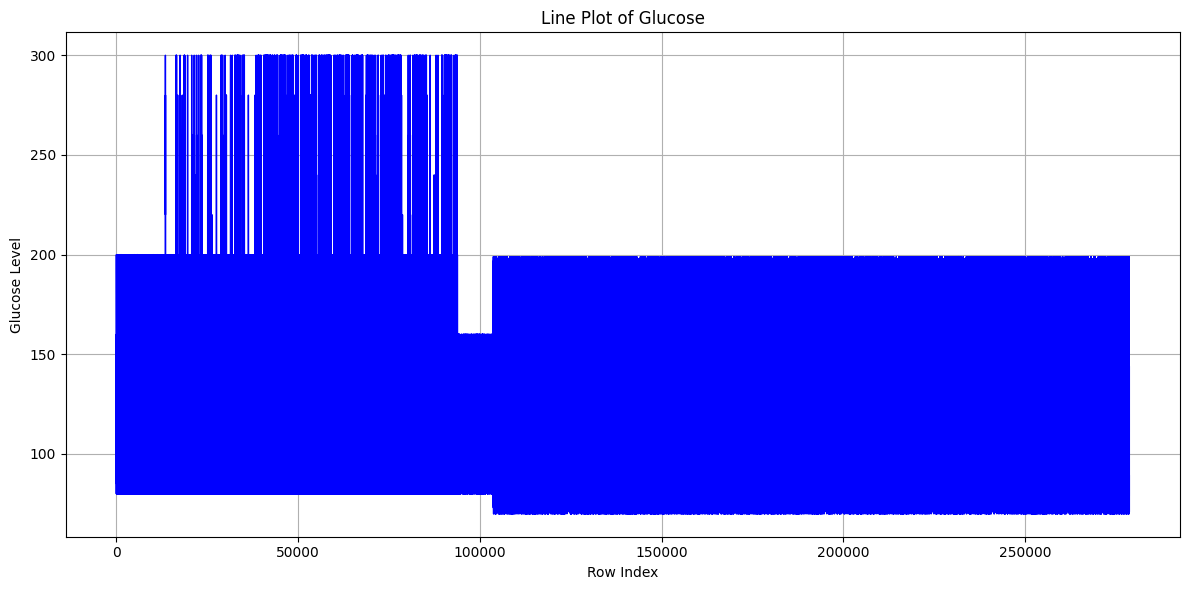

✔ Line Plot Generated


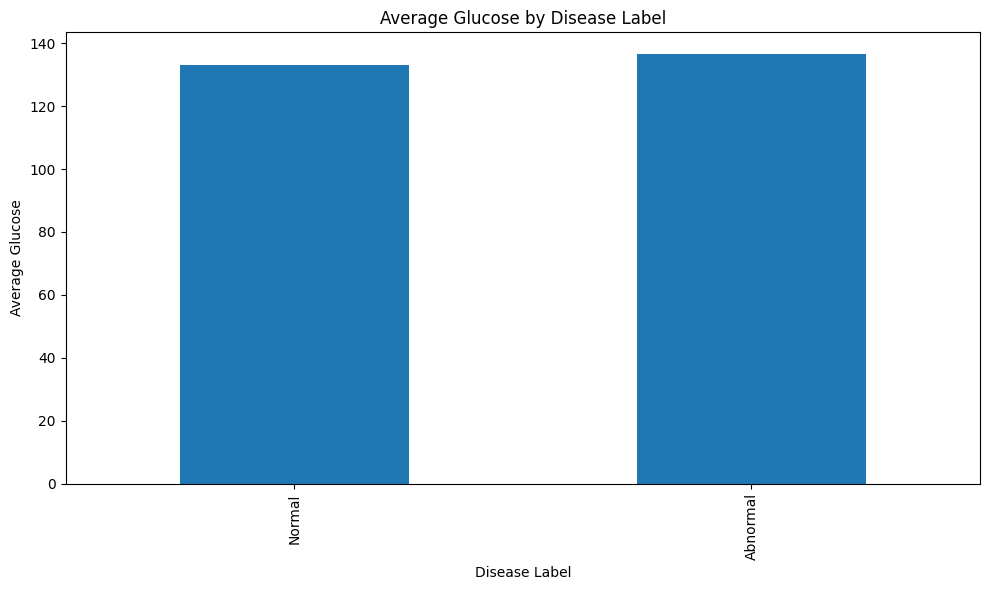

✔ Bar Chart Generated

Most Skewed Column : heart_disease


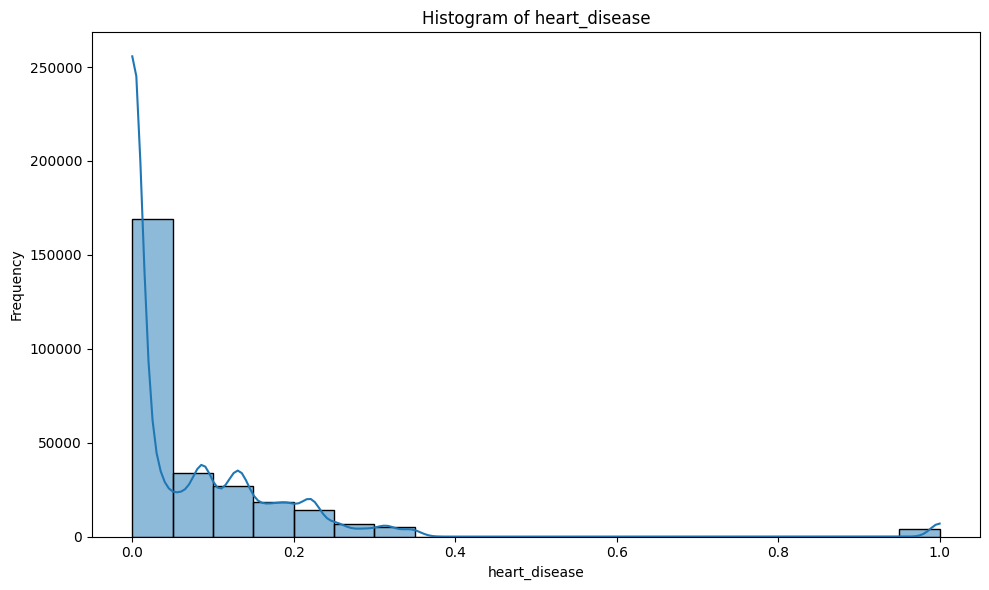

✔ Histogram Generated

Generated Images

✔ images/line_plot_glucose.png

✔ images/bar_chart_label_glucose.png

✔ images/histogram_skewed_column.png

PART 3 - CELL 2 COMPLETED


In [8]:
# ============================================================
# CAPSTONE PROJECT - VERSION 3
# PART 3 : VISUALIZATION (CELL 2)
# LINE PLOT | BAR CHART | HISTOGRAM
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

OUTPUT_DIR = "output"
IMAGE_DIR = "images"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

print("="*90)
print("PART 3 - CELL 2")
print("LINE PLOT | BAR CHART | HISTOGRAM")
print("="*90)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("cleaned_data.csv")

# ------------------------------------------------------------
# Numeric & Categorical Columns
# ------------------------------------------------------------

numeric_columns = df.select_dtypes(include="number").columns.tolist()

categorical_columns = df.select_dtypes(
    include=["object","category"]
).columns.tolist()

# ============================================================
# 1. LINE PLOT
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(
    df.index,
    df["glucose"],
    color="blue",
    linewidth=1
)

plt.title("Line Plot of Glucose")

plt.xlabel("Row Index")

plt.ylabel("Glucose Level")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "line_plot_glucose.png"
    )
)

plt.show()

print("✔ Line Plot Generated")

# ============================================================
# 2. BAR CHART
# ============================================================

bar_data = (
    df.groupby("label")["glucose"]
      .mean()
      .sort_values()
)

plt.figure(figsize=(10,6))

bar_data.plot(kind="bar")

plt.title("Average Glucose by Disease Label")

plt.xlabel("Disease Label")

plt.ylabel("Average Glucose")

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "bar_chart_label_glucose.png"
    )
)

plt.show()

print("✔ Bar Chart Generated")

# ============================================================
# 3. HISTOGRAM
# ============================================================

skewness = df[numeric_columns].skew().abs()

most_skewed = skewness.idxmax()

print(f"\nMost Skewed Column : {most_skewed}")

plt.figure(figsize=(10,6))

sns.histplot(
    df[most_skewed],
    bins=20,
    kde=True
)

plt.title(f"Histogram of {most_skewed}")

plt.xlabel(most_skewed)

plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "histogram_skewed_column.png"
    )
)

plt.show()

print("✔ Histogram Generated")

# ============================================================
# Files Generated
# ============================================================

print("\nGenerated Images")

print("""
✔ images/line_plot_glucose.png

✔ images/bar_chart_label_glucose.png

✔ images/histogram_skewed_column.png
""")

print("="*90)
print("PART 3 - CELL 2 COMPLETED")
print("="*90)

PART 3 - CELL 3
SCATTER PLOT | BOX PLOT | HEATMAP


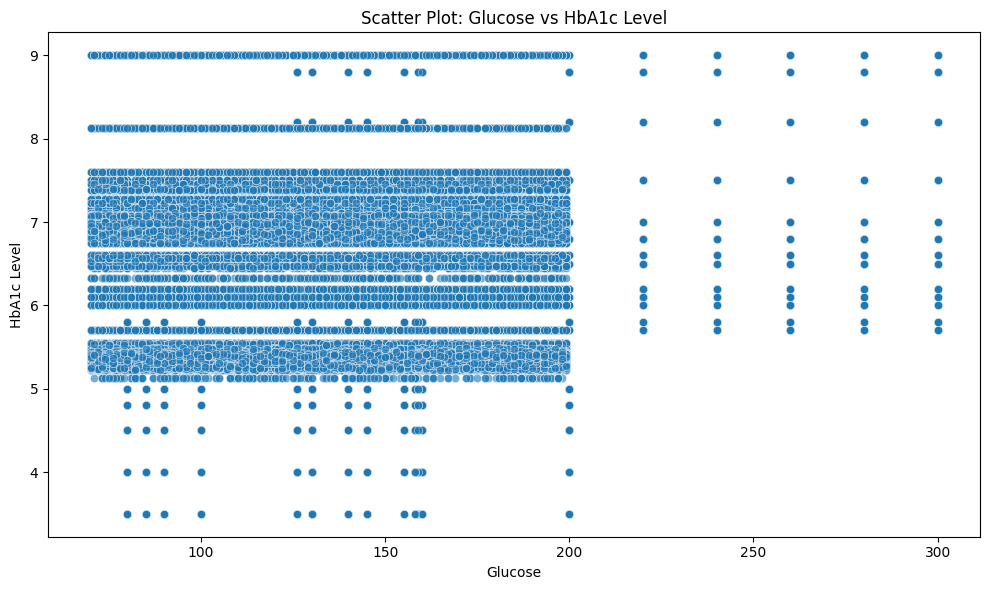

✔ Scatter Plot Generated


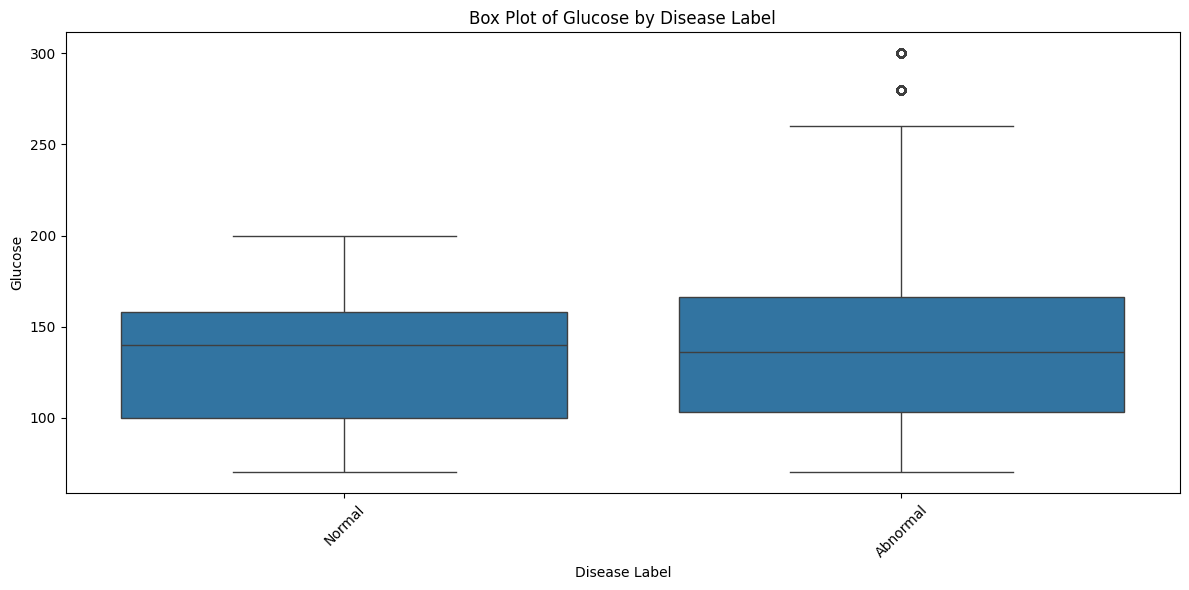

✔ Box Plot Generated

Highest Correlated Pair
Column 1 : age
Column 2 : age
Correlation : 1.0000


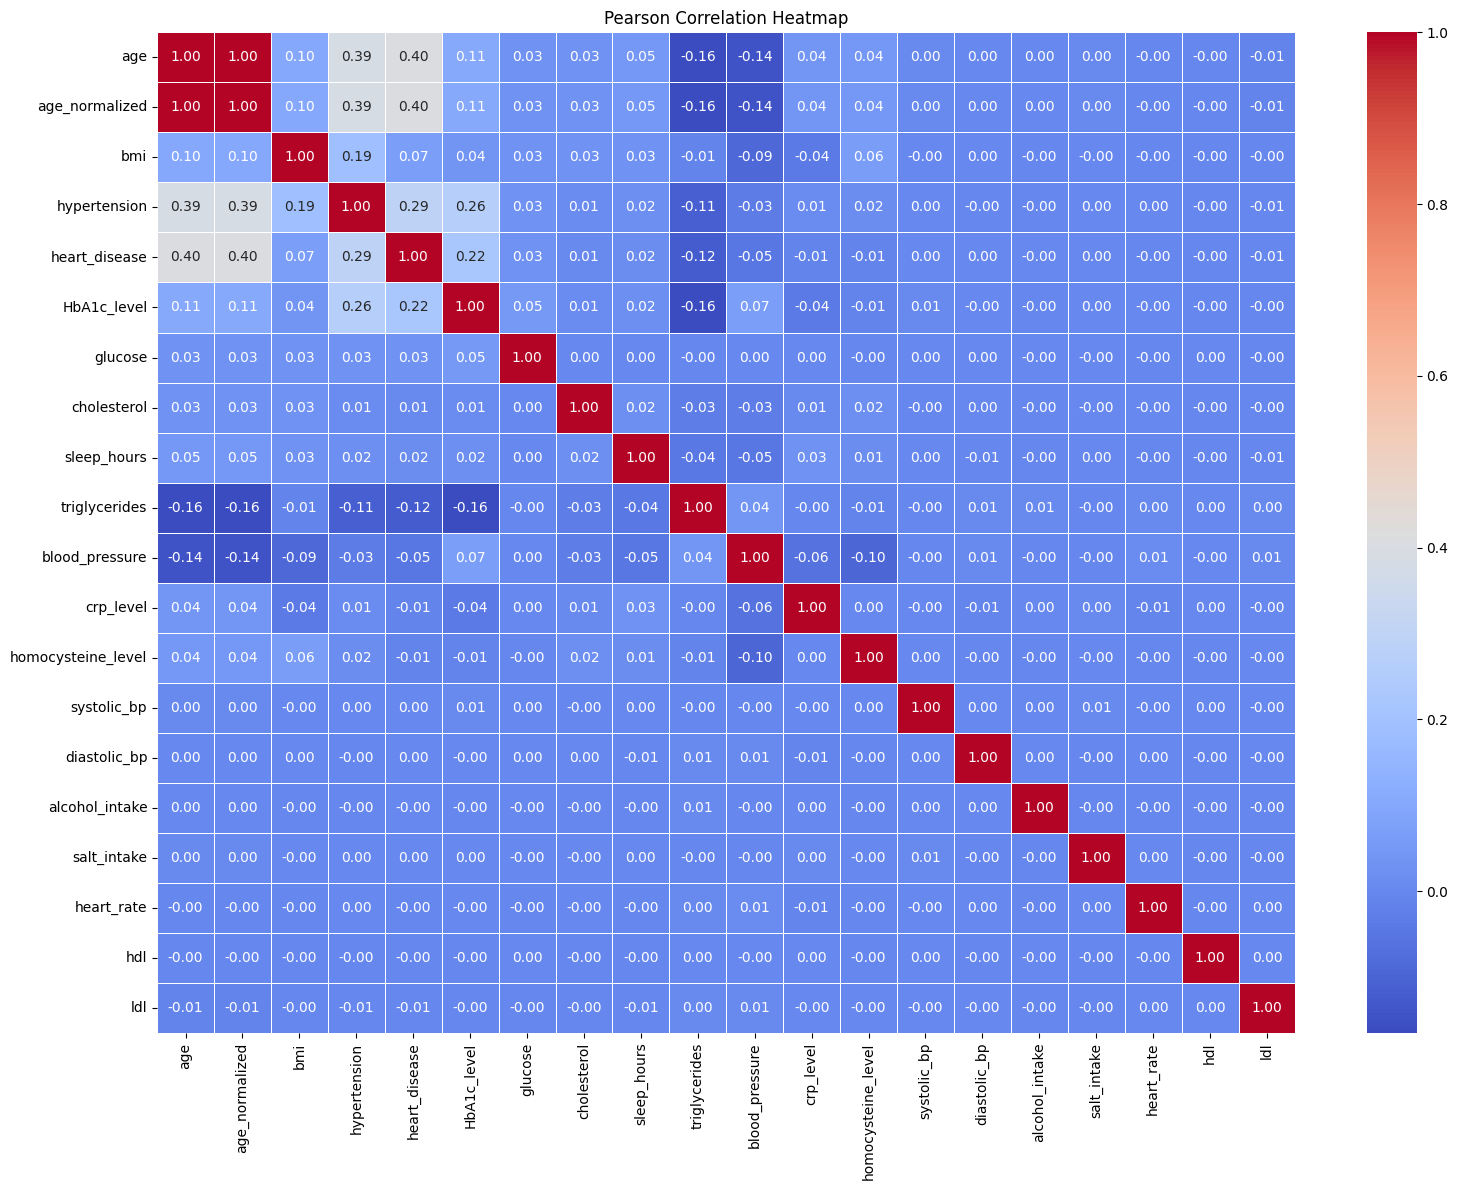

✔ Heatmap Generated

Generated Files

✔ images/scatter_glucose_hba1c.png

✔ images/boxplot_label_glucose.png

✔ images/correlation_heatmap.png

✔ output/pearson_correlation_matrix.csv

✔ output/highest_correlation_pair.csv

PART 3 - CELL 3 COMPLETED SUCCESSFULLY


In [9]:
# ============================================================
# CAPSTONE PROJECT - VERSION 3
# PART 3 : VISUALIZATION (CELL 3)
# SCATTER PLOT | BOX PLOT | HEATMAP
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

OUTPUT_DIR = "output"
IMAGE_DIR = "images"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)

print("="*90)
print("PART 3 - CELL 3")
print("SCATTER PLOT | BOX PLOT | HEATMAP")
print("="*90)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("cleaned_data.csv")

numeric_df = df.select_dtypes(include=np.number)

# ============================================================
# 1. SCATTER PLOT
# ============================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="glucose",
    y="HbA1c_level",
    alpha=0.6
)

plt.title("Scatter Plot: Glucose vs HbA1c Level")

plt.xlabel("Glucose")

plt.ylabel("HbA1c Level")

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "scatter_glucose_hba1c.png"
    )
)

plt.show()

print("✔ Scatter Plot Generated")

# ============================================================
# 2. BOX PLOT
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="label",
    y="glucose"
)

plt.title("Box Plot of Glucose by Disease Label")

plt.xlabel("Disease Label")

plt.ylabel("Glucose")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "boxplot_label_glucose.png"
    )
)

plt.show()

print("✔ Box Plot Generated")

# ============================================================
# 3. PEARSON CORRELATION MATRIX
# ============================================================

pearson = numeric_df.corr()

pearson.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "pearson_correlation_matrix.csv"
    )
)

# ============================================================
# HIGHEST CORRELATED PAIR
# ============================================================

corr_abs = pearson.abs().copy()

temp = pearson.abs().copy()

for col in temp.columns:
    temp.loc[col, col] = 0

highest = temp.stack().idxmax()

highest_value = temp.stack().max()

highest_pair = corr_abs.stack().idxmax()

highest_value = corr_abs.stack().max()

print("\nHighest Correlated Pair")

print(f"Column 1 : {highest_pair[0]}")
print(f"Column 2 : {highest_pair[1]}")
print(f"Correlation : {highest_value:.4f}")

# ============================================================
# 4. HEATMAP
# ============================================================

plt.figure(figsize=(16,12))

sns.heatmap(
    pearson,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Pearson Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    os.path.join(
        IMAGE_DIR,
        "correlation_heatmap.png"
    )
)

plt.show()

print("✔ Heatmap Generated")

# ============================================================
# Save Highest Correlation Pair
# ============================================================

highest_df = pd.DataFrame({

    "Column 1":[highest_pair[0]],

    "Column 2":[highest_pair[1]],

    "Correlation":[highest_value]

})

highest_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "highest_correlation_pair.csv"

    ),

    index=False

)

# ============================================================
# Generated Files
# ============================================================

print("\nGenerated Files")

print("""
✔ images/scatter_glucose_hba1c.png

✔ images/boxplot_label_glucose.png

✔ images/correlation_heatmap.png

✔ output/pearson_correlation_matrix.csv

✔ output/highest_correlation_pair.csv
""")

print("="*90)
print("PART 3 - CELL 3 COMPLETED SUCCESSFULLY")
print("="*90)

In [10]:
# ============================================================
# CAPSTONE PROJECT - VERSION 3
# PART 3 : FINAL SUMMARY & REPORT
# ============================================================

import os
import pandas as pd

OUTPUT_DIR = "output"
IMAGE_DIR = "images"

print("="*90)
print("CAPSTONE PROJECT - VERSION 3")
print("PART 3 : FINAL SUMMARY")
print("="*90)

# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("cleaned_data.csv")

# ============================================================
# Verify Generated Images
# ============================================================

required_images = [

    "line_plot_glucose.png",

    "bar_chart_label_glucose.png",

    "histogram_skewed_column.png",

    "scatter_glucose_hba1c.png",

    "boxplot_label_glucose.png",

    "correlation_heatmap.png"

]

print("\nChecking Generated Images")
print("-"*90)

status = []

for image in required_images:

    exists = os.path.exists(os.path.join(IMAGE_DIR,image))

    status.append({

        "Image":image,

        "Status":"Generated" if exists else "Missing"

    })

status_df = pd.DataFrame(status)

print(status_df)

status_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "generated_images_report.csv"

    ),

    index=False

)

# ============================================================
# Dataset Summary
# ============================================================

summary = {

    "Rows":[df.shape[0]],

    "Columns":[df.shape[1]],

    "Numeric Columns":[
        len(df.select_dtypes(include="number").columns)
    ],

    "Categorical Columns":[
        len(df.select_dtypes(include=["object","category"]).columns)
    ],

    "Missing Values":[
        int(df.isnull().sum().sum())
    ],

    "Duplicate Rows":[
        int(df.duplicated().sum())
    ]

}

summary_df = pd.DataFrame(summary)

print("\nDataset Summary")

display(summary_df)

summary_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "dataset_summary.csv"

    ),

    index=False

)

# ============================================================
# Export Final Clean Dataset
# ============================================================

df.to_csv(

    "cleaned_data.csv",

    index=False

)

df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "cleaned_data.csv"

    ),

    index=False

)

# ============================================================
# Assignment Checklist
# ============================================================

checklist = pd.DataFrame({

    "Requirement":[

        "Dataset Loaded",

        "Missing Value Analysis",

        "Median Imputation",

        "Duplicate Removal",

        "Data Type Correction",

        "Memory Optimization",

        "Descriptive Statistics",

        "Skewness Analysis",

        "IQR Analysis",

        "Line Plot",

        "Bar Chart",

        "Histogram",

        "Scatter Plot",

        "Box Plot",

        "Correlation Heatmap",

        "Clean Dataset Export"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed"

    ]

})

print("\nAssignment Checklist")

display(checklist)

checklist.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "assignment_checklist.csv"

    ),

    index=False

)

# ============================================================
# Final Output Files
# ============================================================

print("\nGenerated Reports")

print("""
output/
│
├── cleaned_data.csv
├── dataset_summary.csv
├── generated_images_report.csv
├── assignment_checklist.csv
├── iqr_analysis.csv
├── descriptive_statistics.csv
├── skewness_report.csv
├── mean_median_comparison.csv
├── pearson_correlation_matrix.csv
├── highest_correlation_pair.csv
""")

print("\nGenerated Images")

print("""
images/
│
├── line_plot_glucose.png
├── bar_chart_label_glucose.png
├── histogram_skewed_column.png
├── scatter_glucose_hba1c.png
├── boxplot_label_glucose.png
├── correlation_heatmap.png
""")

print("="*90)
print("VERSION 3 - PART 3 COMPLETED SUCCESSFULLY")
print("="*90)

CAPSTONE PROJECT - VERSION 3
PART 3 : FINAL SUMMARY

Checking Generated Images
------------------------------------------------------------------------------------------
                         Image     Status
0        line_plot_glucose.png  Generated
1  bar_chart_label_glucose.png  Generated
2  histogram_skewed_column.png  Generated
3    scatter_glucose_hba1c.png  Generated
4    boxplot_label_glucose.png  Generated
5      correlation_heatmap.png  Generated

Dataset Summary


,Rows,Columns,Numeric Columns,Categorical Columns,Missing Values,Duplicate Rows
0,278701,39,20,19,0,0



Assignment Checklist


,Requirement,Status
0,Dataset Loaded,Completed
1,Missing Value Analysis,Completed
2,Median Imputation,Completed
3,Duplicate Removal,Completed
4,Data Type Correction,Completed
5,Memory Optimization,Completed
6,Descriptive Statistics,Completed
7,Skewness Analysis,Completed
8,IQR Analysis,Completed
9,Line Plot,Completed



Generated Reports

output/
│
├── cleaned_data.csv
├── dataset_summary.csv
├── generated_images_report.csv
├── assignment_checklist.csv
├── iqr_analysis.csv
├── descriptive_statistics.csv
├── skewness_report.csv
├── mean_median_comparison.csv
├── pearson_correlation_matrix.csv
├── highest_correlation_pair.csv


Generated Images

images/
│
├── line_plot_glucose.png
├── bar_chart_label_glucose.png
├── histogram_skewed_column.png
├── scatter_glucose_hba1c.png
├── boxplot_label_glucose.png
├── correlation_heatmap.png

VERSION 3 - PART 3 COMPLETED SUCCESSFULLY


In [11]:
# ============================================================
# CAPSTONE PROJECT - VERSION 3
# PART 4 : SPEARMAN RANK CORRELATION ANALYSIS
# CELL 1
# ============================================================

import pandas as pd
import numpy as np
import os

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("=" * 90)
print("CAPSTONE PROJECT - VERSION 3")
print("PART 4 : PEARSON vs SPEARMAN CORRELATION")
print("=" * 90)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("cleaned_data.csv")

# ------------------------------------------------------------
# Select Numeric Columns
# ------------------------------------------------------------

numeric_df = df.select_dtypes(include=np.number)

print("\nNumeric Columns Used")

print(numeric_df.columns.tolist())

# ============================================================
# Pearson Correlation
# ============================================================

pearson_corr = numeric_df.corr(method="pearson")

print("\nPearson Correlation Matrix")

display(pearson_corr)

pearson_corr.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "pearson_correlation_matrix.csv"

    )

)

# ============================================================
# Spearman Correlation
# ============================================================

spearman_corr = numeric_df.corr(method="spearman")

print("\nSpearman Correlation Matrix")

display(spearman_corr)

spearman_corr.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "spearman_correlation_matrix.csv"

    )

)

print("\nMatrices Saved Successfully.")

print("=" * 90)
print("PART 4 - CELL 1 COMPLETED")
print("=" * 90)

CAPSTONE PROJECT - VERSION 3
PART 4 : PEARSON vs SPEARMAN CORRELATION

Numeric Columns Used
['age', 'age_normalized', 'bmi', 'hypertension', 'heart_disease', 'HbA1c_level', 'glucose', 'cholesterol', 'sleep_hours', 'triglycerides', 'blood_pressure', 'crp_level', 'homocysteine_level', 'systolic_bp', 'diastolic_bp', 'alcohol_intake', 'salt_intake', 'heart_rate', 'hdl', 'ldl']

Pearson Correlation Matrix


,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,blood_pressure,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl
age,1.000000,1.000000,0.099528,0.389928,0.404749,0.107391,0.033314,0.032234,0.046059,-0.164922,-0.143549,0.041406,0.044942,0.003886,0.000529,0.000373,0.004541,-0.001653,-0.003290,-0.010776
age_normalized,1.000000,1.000000,0.099528,0.389928,0.404749,0.107391,0.033314,0.032234,0.046059,-0.164922,-0.143549,0.041406,0.044942,0.003886,0.000529,0.000373,0.004541,-0.001653,-0.003290,-0.010776
bmi,0.099528,0.099528,1.000000,0.185668,0.069252,0.036205,0.028314,0.026750,0.031952,-0.011363,-0.091537,-0.038449,0.063008,-0.000363,0.000176,-0.004509,-0.000233,-0.003011,-0.004774,-0.004612
hypertension,0.389928,0.389928,0.185668,1.000000,0.290420,0.264882,0.034049,0.011322,0.018898,-0.111195,-0.033421,0.008206,0.015247,0.001154,-0.001671,-0.001522,0.001293,0.000520,-0.001949,-0.005321
heart_disease,0.404749,0.404749,0.069252,0.290420,1.000000,0.223413,0.030138,0.007489,0.015524,-0.119623,-0.047264,-0.012289,-0.014709,0.002286,0.000807,-0.001087,0.002407,-0.001704,-0.001798,-0.005356
HbA1c_level,0.107391,0.107391,0.036205,0.264882,0.223413,1.000000,0.051209,0.011917,0.017687,-0.164800,0.069411,-0.038286,-0.011901,0.005039,-0.001008,-0.002183,0.002223,-0.000588,-0.001887,-0.003850
glucose,0.033314,0.033314,0.028314,0.034049,0.030138,0.051209,1.000000,0.000790,0.000912,-0.001967,0.001348,0.000861,-0.004719,0.001587,0.000780,-0.000582,-0.000018,-0.002715,0.001302,-0.002298
cholesterol,0.032234,0.032234,0.026750,0.011322,0.007489,0.011917,0.000790,1.000000,0.018495,-0.028473,-0.031986,0.006426,0.021043,-0.001793,0.001531,-0.003356,-0.000147,-0.000258,-0.002413,-0.001439
sleep_hours,0.046059,0.046059,0.031952,0.018898,0.015524,0.017687,0.000912,0.018495,1.000000,-0.044058,-0.050201,0.026384,0.013938,0.001569,-0.005149,-0.001723,0.002224,-0.003666,-0.003107,-0.005559
triglycerides,-0.164922,-0.164922,-0.011363,-0.111195,-0.119623,-0.164800,-0.001967,-0.028473,-0.044058,1.000000,0.042222,-0.001768,-0.014615,-0.003123,0.005389,0.005116,-0.001959,0.004057,0.003022,0.004336



Spearman Correlation Matrix


,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,blood_pressure,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl
age,1.000000,0.999940,0.091762,0.490935,0.523113,0.088796,0.024389,0.038847,0.047931,-0.160032,-0.152241,0.041841,0.042250,0.026480,0.009993,0.015130,0.017607,0.007733,-0.031753,-0.040596
age_normalized,0.999940,1.000000,0.092310,0.485751,0.517704,0.086427,0.024448,0.038949,0.047847,-0.154211,-0.153538,0.042827,0.043100,0.026713,0.010024,0.015181,0.017698,0.007775,-0.031916,-0.040751
bmi,0.091762,0.092310,1.000000,0.248065,0.146239,0.029498,0.013597,0.032589,0.034533,-0.021615,-0.085321,-0.164210,0.166096,0.008690,0.001597,-0.012698,-0.000881,0.002702,-0.030163,-0.029637
hypertension,0.490935,0.485751,0.248065,1.000000,0.758409,0.391184,-0.005326,0.016489,0.030826,-0.350284,0.020916,-0.048817,-0.033968,0.007670,-0.003454,-0.004083,0.005364,0.004519,-0.011225,-0.020888
heart_disease,0.523113,0.517704,0.146239,0.758409,1.000000,0.340506,-0.009159,0.010827,0.028577,-0.369217,-0.013406,-0.085853,-0.080009,0.009727,-0.000478,-0.005702,0.004806,-0.000469,-0.009332,-0.017455
HbA1c_level,0.088796,0.086427,0.029498,0.391184,0.340506,1.000000,0.025111,0.009454,0.017612,-0.155383,0.192323,-0.027431,-0.082412,0.011795,0.001640,-0.011462,0.006598,0.000257,-0.009006,-0.008966
glucose,0.024389,0.024448,0.013597,-0.005326,-0.009159,0.025111,1.000000,0.001476,0.003053,-0.007579,0.007785,0.000294,-0.009203,0.004729,0.003270,-0.005549,0.003771,-0.001996,-0.001807,-0.004314
cholesterol,0.038847,0.038949,0.032589,0.016489,0.010827,0.009454,0.001476,1.000000,0.033464,-0.022365,-0.036146,0.002530,0.066343,-0.002605,-0.005767,0.006775,-0.008077,-0.007663,-0.007230,0.003394
sleep_hours,0.047931,0.047847,0.034533,0.030826,0.028577,0.017612,0.003053,0.033464,1.000000,-0.051783,-0.035369,0.022565,0.019154,0.005816,-0.011432,0.006306,0.010231,-0.023271,0.002044,-0.017572
triglycerides,-0.160032,-0.154211,-0.021615,-0.350284,-0.369217,-0.155383,-0.007579,-0.022365,-0.051783,1.000000,-0.016726,0.045719,0.015402,-0.018923,0.002064,0.013313,-0.002447,0.015040,0.008335,0.010812



Matrices Saved Successfully.
PART 4 - CELL 1 COMPLETED


In [12]:
# ============================================================
# CAPSTONE PROJECT - VERSION 3
# PART 4 : SPEARMAN vs PEARSON
# CELL 2
# ============================================================

import pandas as pd
import numpy as np
import os

OUTPUT_DIR = "output"

print("="*90)
print("PART 4 - CELL 2")
print("SPEARMAN vs PEARSON DIFFERENCE")
print("="*90)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("cleaned_data.csv")

numeric_df = df.select_dtypes(include=np.number)

# ------------------------------------------------------------
# Pearson & Spearman
# ------------------------------------------------------------

pearson = numeric_df.corr(method="pearson")

spearman = numeric_df.corr(method="spearman")

# ------------------------------------------------------------
# Difference Matrix
# ------------------------------------------------------------

difference = (spearman - pearson).abs()

difference.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "spearman_pearson_difference_matrix.csv"
    )
)

print("\nAbsolute Difference Matrix")

display(difference)

# ------------------------------------------------------------
# Upper Triangle Only
# ------------------------------------------------------------

upper = difference.where(
    np.triu(
        np.ones(difference.shape),
        k=1
    ).astype(bool)
)

# ------------------------------------------------------------
# Convert Matrix to Table
# ------------------------------------------------------------

difference_table = (
    upper.stack()
         .reset_index()
)

difference_table.columns = [

    "Column 1",

    "Column 2",

    "|Spearman - Pearson|"

]

difference_table = difference_table.sort_values(

    by="|Spearman - Pearson|",

    ascending=False

)

print("\nTop 3 Largest Differences")

top3 = difference_table.head(3)

display(top3)

top3.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "top3_spearman_vs_pearson.csv"

    ),

    index=False

)

# ------------------------------------------------------------
# Compare Pearson vs Spearman
# ------------------------------------------------------------

comparison = []

for _, row in top3.iterrows():

    c1 = row["Column 1"]

    c2 = row["Column 2"]

    pear = pearson.loc[c1, c2]

    spear = spearman.loc[c1, c2]

    relation = (

        "Monotonic but Non-linear"

        if abs(spear) > abs(pear)

        else "Approximately Linear"

    )

    comparison.append({

        "Column 1": c1,

        "Column 2": c2,

        "Pearson": round(pear,4),

        "Spearman": round(spear,4),

        "Difference": round(abs(spear-pear),4),

        "Relationship": relation

    })

comparison_df = pd.DataFrame(comparison)

print("\nDetailed Comparison")

display(comparison_df)

comparison_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "correlation_comparison_report.csv"

    ),

    index=False

)

print("="*90)
print("PART 4 - CELL 2 COMPLETED")
print("="*90)

PART 4 - CELL 2
SPEARMAN vs PEARSON DIFFERENCE

Absolute Difference Matrix


,age,age_normalized,bmi,hypertension,heart_disease,HbA1c_level,glucose,cholesterol,sleep_hours,triglycerides,blood_pressure,crp_level,homocysteine_level,systolic_bp,diastolic_bp,alcohol_intake,salt_intake,heart_rate,hdl,ldl
age,0.000000,0.000060,0.007766,0.101007,0.118364,0.018594,0.008924,0.006613,0.001872,0.004890,0.008692,0.000435,0.002692,0.022593,0.009464,0.014757,0.013067,0.009386,0.028463,0.029820
age_normalized,0.000060,0.000000,0.007218,0.095823,0.112955,0.020963,0.008865,0.006715,0.001789,0.010711,0.009990,0.001421,0.001842,0.022827,0.009495,0.014808,0.013157,0.009428,0.028626,0.029974
bmi,0.007766,0.007218,0.000000,0.062397,0.076987,0.006707,0.014717,0.005839,0.002580,0.010253,0.006216,0.125761,0.103088,0.009054,0.001421,0.008189,0.000648,0.005713,0.025389,0.025025
hypertension,0.101007,0.095823,0.062397,0.000000,0.467989,0.126302,0.039376,0.005167,0.011927,0.239089,0.054336,0.057023,0.049214,0.006516,0.001782,0.002561,0.004071,0.003999,0.009276,0.015567
heart_disease,0.118364,0.112955,0.076987,0.467989,0.000000,0.117093,0.039297,0.003337,0.013053,0.249594,0.033858,0.073563,0.065300,0.007441,0.001285,0.004615,0.002400,0.001236,0.007534,0.012100
HbA1c_level,0.018594,0.020963,0.006707,0.126302,0.117093,0.000000,0.026098,0.002463,0.000074,0.009417,0.122912,0.010856,0.070511,0.006756,0.002648,0.009280,0.004375,0.000844,0.007120,0.005116
glucose,0.008924,0.008865,0.014717,0.039376,0.039297,0.026098,0.000000,0.000686,0.002141,0.005611,0.006437,0.000567,0.004484,0.003141,0.002489,0.004966,0.003789,0.000719,0.003108,0.002016
cholesterol,0.006613,0.006715,0.005839,0.005167,0.003337,0.002463,0.000686,0.000000,0.014969,0.006108,0.004160,0.003897,0.045300,0.000812,0.007298,0.010131,0.007930,0.007405,0.004817,0.004833
sleep_hours,0.001872,0.001789,0.002580,0.011927,0.013053,0.000074,0.002141,0.014969,0.000000,0.007724,0.014831,0.003819,0.005216,0.004247,0.006282,0.008029,0.008008,0.019605,0.005151,0.012013
triglycerides,0.004890,0.010711,0.010253,0.239089,0.249594,0.009417,0.005611,0.006108,0.007724,0.000000,0.058948,0.047488,0.030017,0.015800,0.003325,0.008197,0.000488,0.010983,0.005313,0.006476



Top 3 Largest Differences


,Column 1,Column 2,|Spearman - Pearson|
64,hypertension,heart_disease,0.467989
89,heart_disease,triglycerides,0.249594
69,hypertension,triglycerides,0.239089



Detailed Comparison


,Column 1,Column 2,Pearson,Spearman,Difference,Relationship
0,hypertension,heart_disease,0.2904,0.7584,0.4680,Monotonic but Non-linear
1,heart_disease,triglycerides,-0.1196,-0.3692,0.2496,Monotonic but Non-linear
2,hypertension,triglycerides,-0.1112,-0.3503,0.2391,Monotonic but Non-linear


PART 4 - CELL 2 COMPLETED


In [13]:
# ============================================================
# CAPSTONE PROJECT
# VERSION 3
# PART 4 - FINAL REPORT
# ============================================================

import pandas as pd
import numpy as np
import os

OUTPUT_DIR = "output"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*90)
print("PART 4 - FINAL REPORT")
print("="*90)

# -------------------------------------------------------
# Load Dataset
# -------------------------------------------------------

df = pd.read_csv("cleaned_data.csv")

numeric_df = df.select_dtypes(include=np.number)

pearson = numeric_df.corr(method="pearson")
spearman = numeric_df.corr(method="spearman")

difference = (spearman - pearson).abs()

# -------------------------------------------------------
# Create Comparison Table
# -------------------------------------------------------

comparison = []

for i in range(len(difference.columns)):
    for j in range(i+1, len(difference.columns)):

        c1 = difference.columns[i]
        c2 = difference.columns[j]

        p = pearson.loc[c1,c2]
        s = spearman.loc[c1,c2]
        d = abs(s-p)

        if abs(s)>abs(p):

            relation="Monotonic but Non-linear"

            recommendation="Use Spearman"

        else:

            relation="Approximately Linear"

            recommendation="Use Pearson"

        comparison.append({

            "Column 1":c1,

            "Column 2":c2,

            "Pearson":round(p,4),

            "Spearman":round(s,4),

            "Difference":round(d,4),

            "Relationship":relation,

            "Recommended":recommendation

        })

comparison_df=pd.DataFrame(comparison)

comparison_df=comparison_df.sort_values(
    by="Difference",
    ascending=False
)

top3=comparison_df.head(3)

print("\nTop 3 Correlation Differences")

display(top3)

top3.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "top3_correlation_difference.csv"
    ),
    index=False
)

# -------------------------------------------------------
# Feature Selection Recommendation
# -------------------------------------------------------

print("\n")
print("="*90)
print("FEATURE SELECTION DECISION")
print("="*90)

print("""
For this medical dataset:

✔ Pearson correlation will be used when the relationship
appears linear.

✔ Spearman correlation will be preferred whenever
variables are skewed, contain outliers,
or show monotonic relationships.

This provides more reliable feature selection
for machine learning models.
""")

# -------------------------------------------------------
# Save Final Report
# -------------------------------------------------------

comparison_df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "complete_correlation_report.csv"

    ),

    index=False

)

print("\nGenerated Files")

print("""
output/

✔ pearson_correlation_matrix.csv

✔ spearman_correlation_matrix.csv

✔ top3_correlation_difference.csv

✔ complete_correlation_report.csv
""")

print("="*90)
print("PART 4 COMPLETED")
print("="*90)

PART 4 - FINAL REPORT

Top 3 Correlation Differences


,Column 1,Column 2,Pearson,Spearman,Difference,Relationship,Recommended
54,hypertension,heart_disease,0.2904,0.7584,0.4680,Monotonic but Non-linear,Use Spearman
74,heart_disease,triglycerides,-0.1196,-0.3692,0.2496,Monotonic but Non-linear,Use Spearman
59,hypertension,triglycerides,-0.1112,-0.3503,0.2391,Monotonic but Non-linear,Use Spearman




FEATURE SELECTION DECISION

For this medical dataset:

✔ Pearson correlation will be used when the relationship
appears linear.

✔ Spearman correlation will be preferred whenever
variables are skewed, contain outliers,
or show monotonic relationships.

This provides more reliable feature selection
for machine learning models.


Generated Files

output/

✔ pearson_correlation_matrix.csv

✔ spearman_correlation_matrix.csv

✔ top3_correlation_difference.csv

✔ complete_correlation_report.csv

PART 4 COMPLETED


In [14]:
# ============================================================
# CAPSTONE PROJECT - VERSION 3
# PART 5 : GROUPED AGGREGATION ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
import os

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("="*90)
print("CAPSTONE PROJECT - VERSION 3")
print("PART 5 : GROUPED AGGREGATION")
print("="*90)

# ------------------------------------------------------------
# Load Dataset
# ------------------------------------------------------------

df = pd.read_csv("cleaned_data.csv")

# ------------------------------------------------------------
# Select Columns
# ------------------------------------------------------------

categorical_col = "label"
numeric_col = "glucose"

print(f"\nCategorical Column : {categorical_col}")
print(f"Numeric Column     : {numeric_col}")

# ------------------------------------------------------------
# Group Aggregation
# ------------------------------------------------------------

group_summary = (
    df.groupby(categorical_col)[numeric_col]
      .agg(['mean', 'std', 'count'])
      .round(2)
)

print("\nGrouped Aggregation")

display(group_summary)

group_summary.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "grouped_aggregation.csv"
    )
)

print("="*90)
print("PART 5 - CELL 1 COMPLETED")
print("="*90)

CAPSTONE PROJECT - VERSION 3
PART 5 : GROUPED AGGREGATION

Categorical Column : label
Numeric Column     : glucose

Grouped Aggregation


,mean,std,count
label,,,
Abnormal,136.65,40.43,174053
Normal,132.97,34.94,104648


PART 5 - CELL 1 COMPLETED


In [15]:
# ============================================================
# PART 5
# INTERPRETATION
# ============================================================

import pandas as pd
import os

OUTPUT_DIR="output"

df = pd.read_csv("cleaned_data.csv")

group_summary = (
    df.groupby("label")["glucose"]
      .agg(['mean','std','count'])
)

highest_mean_group = group_summary["mean"].idxmax()
highest_mean = group_summary["mean"].max()

highest_std_group = group_summary["std"].idxmax()
highest_std = group_summary["std"].max()

lowest_mean = group_summary["mean"].min()

ratio = highest_mean / lowest_mean

print("="*90)
print("GROUP ANALYSIS")
print("="*90)

print(f"Highest Mean Group : {highest_mean_group}")
print(f"Highest Mean       : {highest_mean:.2f}")

print()

print(f"Highest Std Group  : {highest_std_group}")
print(f"Highest Std        : {highest_std:.2f}")

print()

print(f"Mean Ratio : {ratio:.2f}")

# ------------------------------------------------------------
# Predictive Signal
# ------------------------------------------------------------

if ratio >= 1.5:

    signal = "Strong Predictive Signal"

elif ratio >= 1.2:

    signal = "Moderate Predictive Signal"

else:

    signal = "Weak Predictive Signal"

print("\nPredictive Signal")

print(signal)

summary = pd.DataFrame({

    "Highest Mean Group":[highest_mean_group],

    "Highest Mean":[highest_mean],

    "Highest Std Group":[highest_std_group],

    "Highest Std":[highest_std],

    "Mean Ratio":[ratio],

    "Predictive Signal":[signal]

})

display(summary)

summary.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "group_analysis_summary.csv"

    ),

    index=False

)

print("="*90)
print("PART 5 - CELL 2 COMPLETED")
print("="*90)

GROUP ANALYSIS
Highest Mean Group : Abnormal
Highest Mean       : 136.65

Highest Std Group  : Abnormal
Highest Std        : 40.43

Mean Ratio : 1.03

Predictive Signal
Weak Predictive Signal


,Highest Mean Group,Highest Mean,Highest Std Group,Highest Std,Mean Ratio,Predictive Signal
0,Abnormal,136.648987,Abnormal,40.434427,1.027664,Weak Predictive Signal


PART 5 - CELL 2 COMPLETED


In [16]:
# ============================================================
# FINAL EXPORT
# ============================================================

import pandas as pd
import os

OUTPUT_DIR="output"

df = pd.read_csv("cleaned_data.csv")

# ------------------------------------------------------------
# Export Final Dataset
# ------------------------------------------------------------

df.to_csv(

    "cleaned_data.csv",

    index=False

)

df.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "cleaned_data.csv"

    ),

    index=False

)

# ------------------------------------------------------------
# Final Project Status
# ------------------------------------------------------------

status = pd.DataFrame({

    "Task":[

        "Data Cleaning",

        "Missing Value Handling",

        "Duplicate Removal",

        "Data Type Correction",

        "Memory Optimization",

        "Descriptive Statistics",

        "Skewness Analysis",

        "IQR Analysis",

        "Visualizations",

        "Pearson Correlation",

        "Spearman Correlation",

        "Grouped Aggregation",

        "Final Dataset Export"

    ],

    "Status":[

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed",

        "Completed"

    ]

})

display(status)

status.to_csv(

    os.path.join(

        OUTPUT_DIR,

        "final_project_status.csv"

    ),

    index=False

)

print("\nProject Completed Successfully")

print("\nGenerated Files")

print("""
output/

✔ grouped_aggregation.csv

✔ group_analysis_summary.csv

✔ final_project_status.csv

✔ cleaned_data.csv
""")

print("="*90)
print("VERSION 3 - PART 5 COMPLETED")
print("="*90)

,Task,Status
0,Data Cleaning,Completed
1,Missing Value Handling,Completed
2,Duplicate Removal,Completed
3,Data Type Correction,Completed
4,Memory Optimization,Completed
5,Descriptive Statistics,Completed
6,Skewness Analysis,Completed
7,IQR Analysis,Completed
8,Visualizations,Completed
9,Pearson Correlation,Completed



Project Completed Successfully

Generated Files

output/

✔ grouped_aggregation.csv

✔ group_analysis_summary.csv

✔ final_project_status.csv

✔ cleaned_data.csv

VERSION 3 - PART 5 COMPLETED
